# Model Fitting Supporting Material

## [Tidy Tuesday Spotify Dataset](https://github.com/rfordatascience/tidytuesday/tree/main/data/2020/2020-01-21)

Author: [Ashley Kennedy](ashley.g.kennedy@gmail.com)

## Import Modules and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import statsmodels.formula.api as smf

In [3]:
spotify_copy = pd.read_csv('spotify_copy.csv')

In [4]:
spotify_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32246 entries, 0 to 32245
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_popularity    32246 non-null  int64  
 1   playlist_genre      32246 non-null  object 
 2   playlist_subgenre   32246 non-null  object 
 3   danceability        32246 non-null  float64
 4   energy              32246 non-null  float64
 5   key                 32246 non-null  object 
 6   loudness            32246 non-null  float64
 7   mode                32246 non-null  object 
 8   speechiness         32246 non-null  float64
 9   acousticness        32246 non-null  float64
 10  instrumentalness    32246 non-null  float64
 11  liveness            32246 non-null  float64
 12  valence             32246 non-null  float64
 13  tempo               32246 non-null  float64
 14  duration_ms         32246 non-null  int64  
 15  release_month       32246 non-null  int64  
 16  rele

In [5]:
cont_vars = ['danceability', 'energy', 'loudness', 'log_speechiness', 'logit_acousticness', 'instrumentalness', 'sqrt_liveness', 'valence', 'tempo']

### Create the formula list

In [6]:
formula_list = [
    'y ~ 1',
    'y ~ playlist_genre + mode + key + release_month + bin_year',
    'y ~ danceability + energy + loudness + log_speechiness + logit_acousticness + instrumentalness + sqrt_liveness + valence + tempo + duration_ms',
    'y ~ playlist_genre + mode + key + release_month + bin_year + danceability + energy + loudness + log_speechiness + logit_acousticness + instrumentalness + sqrt_liveness + valence + tempo + duration_ms',
    'y ~ (danceability + energy + loudness + log_speechiness + logit_acousticness + instrumentalness + sqrt_liveness + valence + tempo + duration_ms) ** 2',
    'y ~ (playlist_genre + mode + key + release_month + bin_year) * (danceability + energy + loudness + log_speechiness + logit_acousticness + instrumentalness + sqrt_liveness + valence + tempo + duration_ms)',
    'y ~ (playlist_genre * loudness * energy)',
    'y ~ (playlist_genre + loudness + energy) ** 2 + mode + key + danceability + valence + tempo'
    ]

### Define coefficient plot to display significant coefficients

This coefficient plot will display each significant coefficient for each model with the 95% confidence interval. All non-significant features will be excluded from the plots.

In [7]:
def my_coefplot(mod, figsize_use=(10, 5)):

    # significant values
    sig = mod.pvalues < 0.05

    sig_params = mod.params[sig]
    sig_bse = mod.bse[sig]

    # non significant values
    non_sig = mod.pvalues > 0.05

    non_sig_params = mod.params[non_sig]
    non_sig_bse = mod.bse[non_sig]

    fig, ax = plt.subplots(figsize=figsize_use)

    # plot significant values with color red
    ax.errorbar(y=sig_params.index,
                x=sig_params,
                xerr= 2 * sig_bse,
                fmt='o', color='r', ecolor='r', elinewidth=2, ms=10,
                label='significant (p-value < 0.05)')
    
    # plot non-significant values with color grey
    ax.errorbar(y=non_sig_params.index,
                x=non_sig_params,
                xerr= 2 * non_sig_bse,
                fmt='o', color='grey', ecolor='grey', elinewidth=2, ms=10,
                label='non-significant')
    
    ax.axvline(x=0, linestyle='--', linewidth=3.5, color='grey')

    ax.set_xlabel('coefficient value')
    ax.legend()

    plt.show()

### Fit Intercept Only Model

In [8]:
mod_00 = smf.ols(formula=formula_list[0], data=spotify_copy).fit()

In [9]:
print(mod_00.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 07 Dec 2025   Prob (F-statistic):                nan
Time:                        20:22:23   Log-Likelihood:                -71213.
No. Observations:               32246   AIC:                         1.424e+05
Df Residuals:                   32245   BIC:                         1.424e+05
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8369      0.012    -68.238      0.0

In [10]:
mod_00.pvalues

Intercept    0.0
dtype: float64

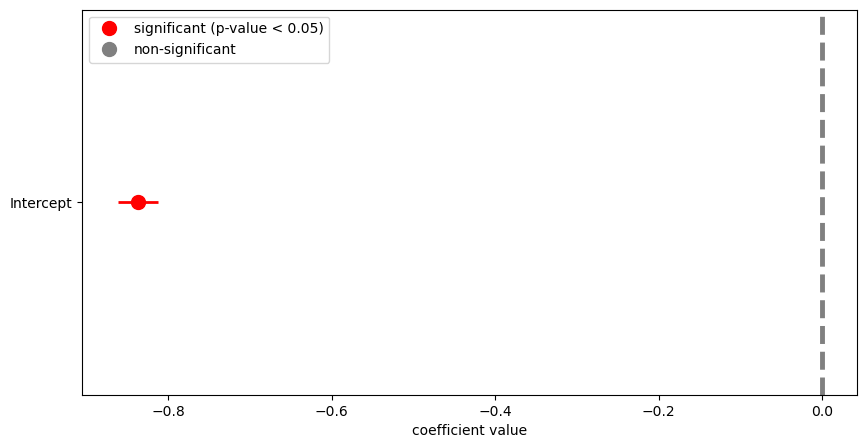

In [11]:
my_coefplot(mod_00)

### Categorical inputs with additive features

In [12]:
mod_01 = smf.ols(formula=formula_list[1], data=spotify_copy).fit()

In [13]:
print(mod_01.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     69.10
Date:                Sun, 07 Dec 2025   Prob (F-statistic):          2.01e-261
Time:                        20:22:23   Log-Likelihood:                -70570.
No. Observations:               32246   AIC:                         1.412e+05
Df Residuals:                   32226   BIC:                         1.413e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

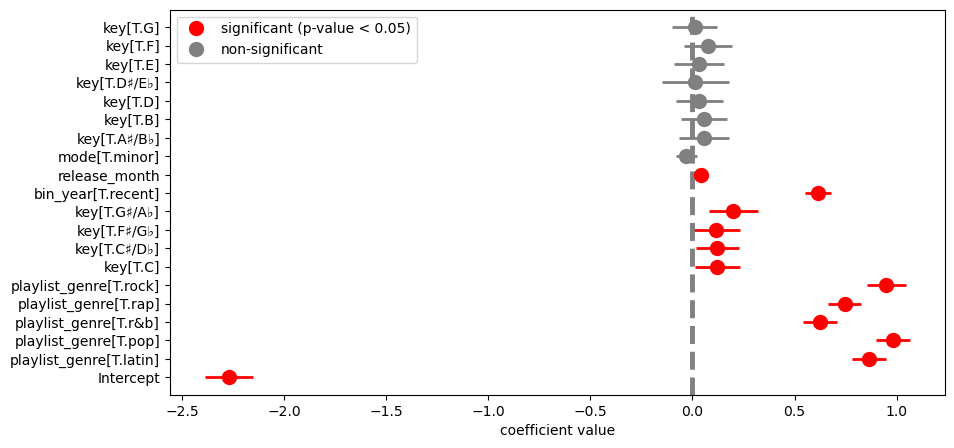

In [14]:
my_coefplot(mod_01)

### Continuous inputs with linear additive features

In [15]:
mod_02 = smf.ols(formula=formula_list[2], data=spotify_copy).fit()

In [16]:
print(mod_02.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     182.3
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        20:22:24   Log-Likelihood:                -70326.
No. Observations:               32246   AIC:                         1.407e+05
Df Residuals:                   32235   BIC:                         1.408e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.6695      0

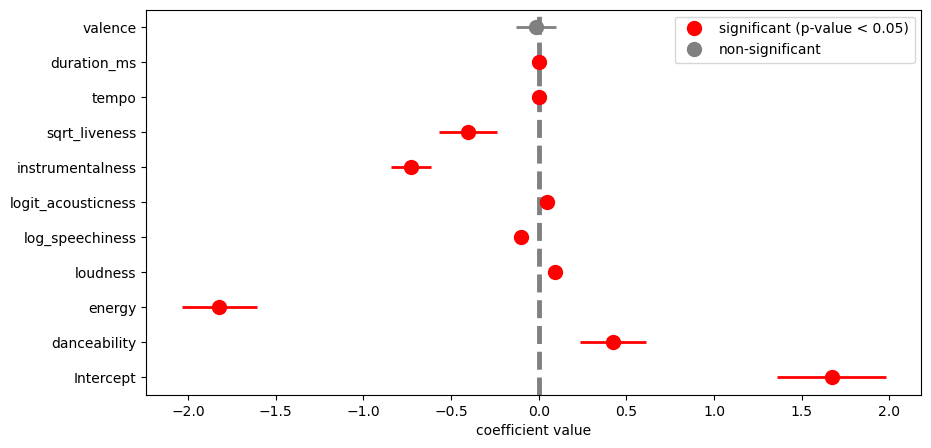

In [17]:
my_coefplot(mod_02)

### All inputs with linear additive features

In [18]:
mod_03 = smf.ols(formula=formula_list[3], data=spotify_copy).fit()

In [19]:
print(mod_03.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     90.78
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        20:22:24   Log-Likelihood:                -69947.
No. Observations:               32246   AIC:                         1.400e+05
Df Residuals:                   32216   BIC:                         1.402e+05
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

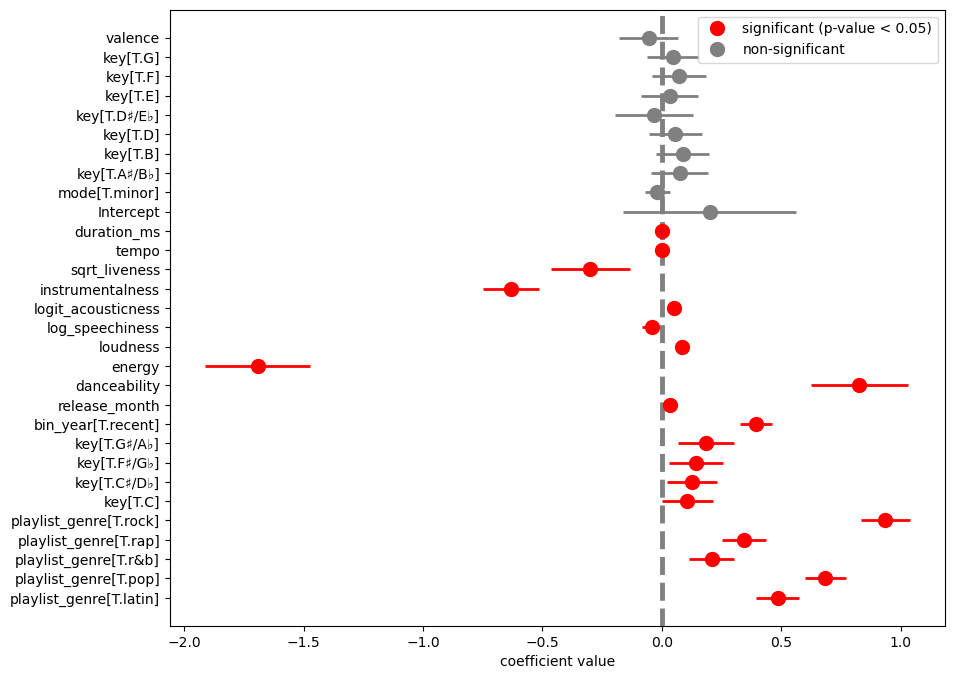

In [20]:
my_coefplot(mod_03, figsize_use=(10,8))

### Continuous inputs with linear main effect and pair-wise interactions

In [21]:
mod_04 = smf.ols(formula=formula_list[4], data=spotify_copy).fit()

In [22]:
print(mod_04.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     42.67
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        20:22:26   Log-Likelihood:                -70079.
No. Observations:               32246   AIC:                         1.403e+05
Df Residuals:                   32190   BIC:                         1.407e+05
Df Model:                          55                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

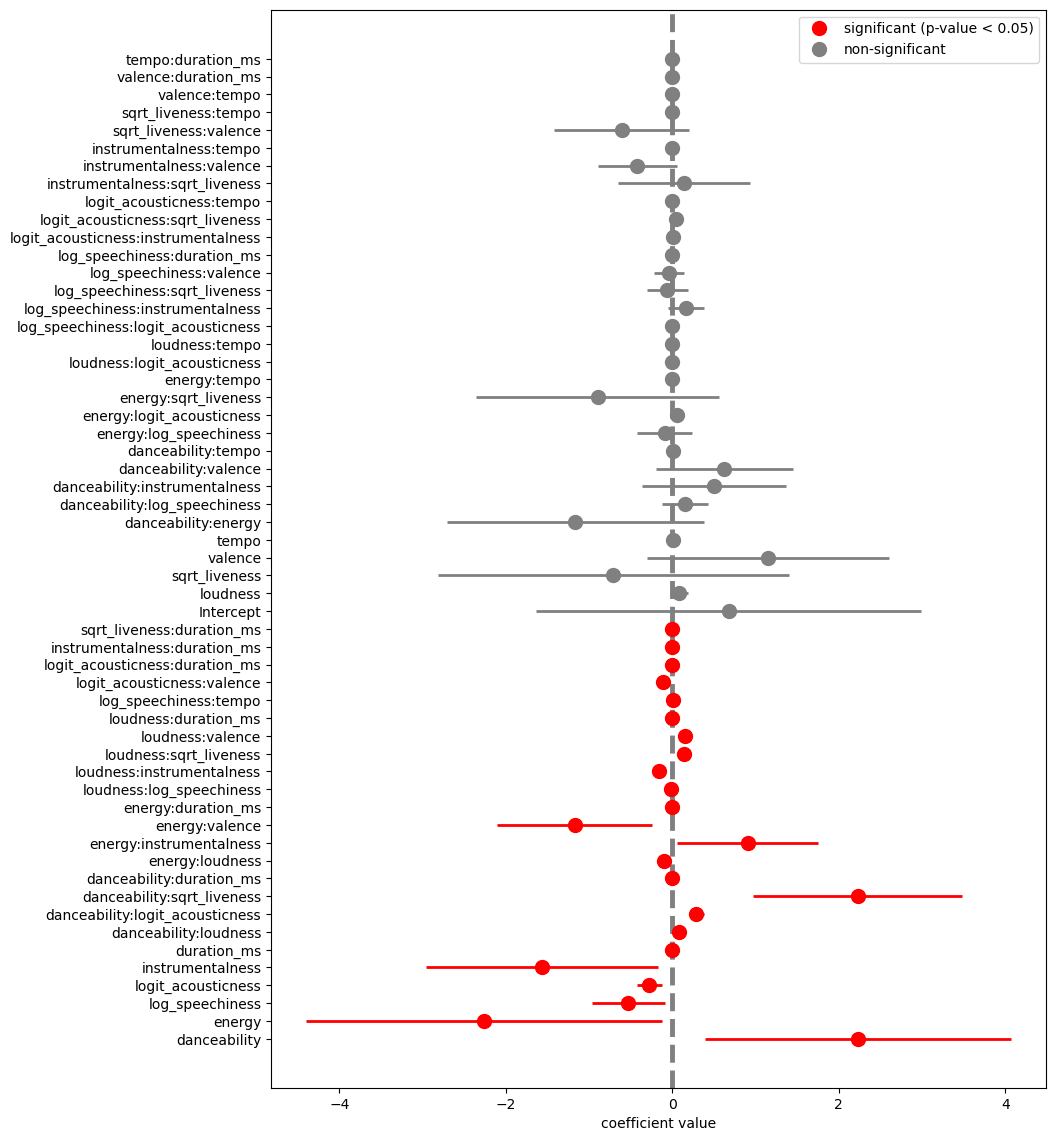

In [23]:
my_coefplot(mod_04, figsize_use=(10,14))

### Categorical and continuous interactions

In [24]:
mod_05 = smf.ols(formula=formula_list[5], data=spotify_copy).fit()

In [25]:
print(mod_05.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     17.17
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        20:22:30   Log-Likelihood:                -69423.
No. Observations:               32246   AIC:                         1.393e+05
Df Residuals:                   32026   BIC:                         1.411e+05
Df Model:                         219                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

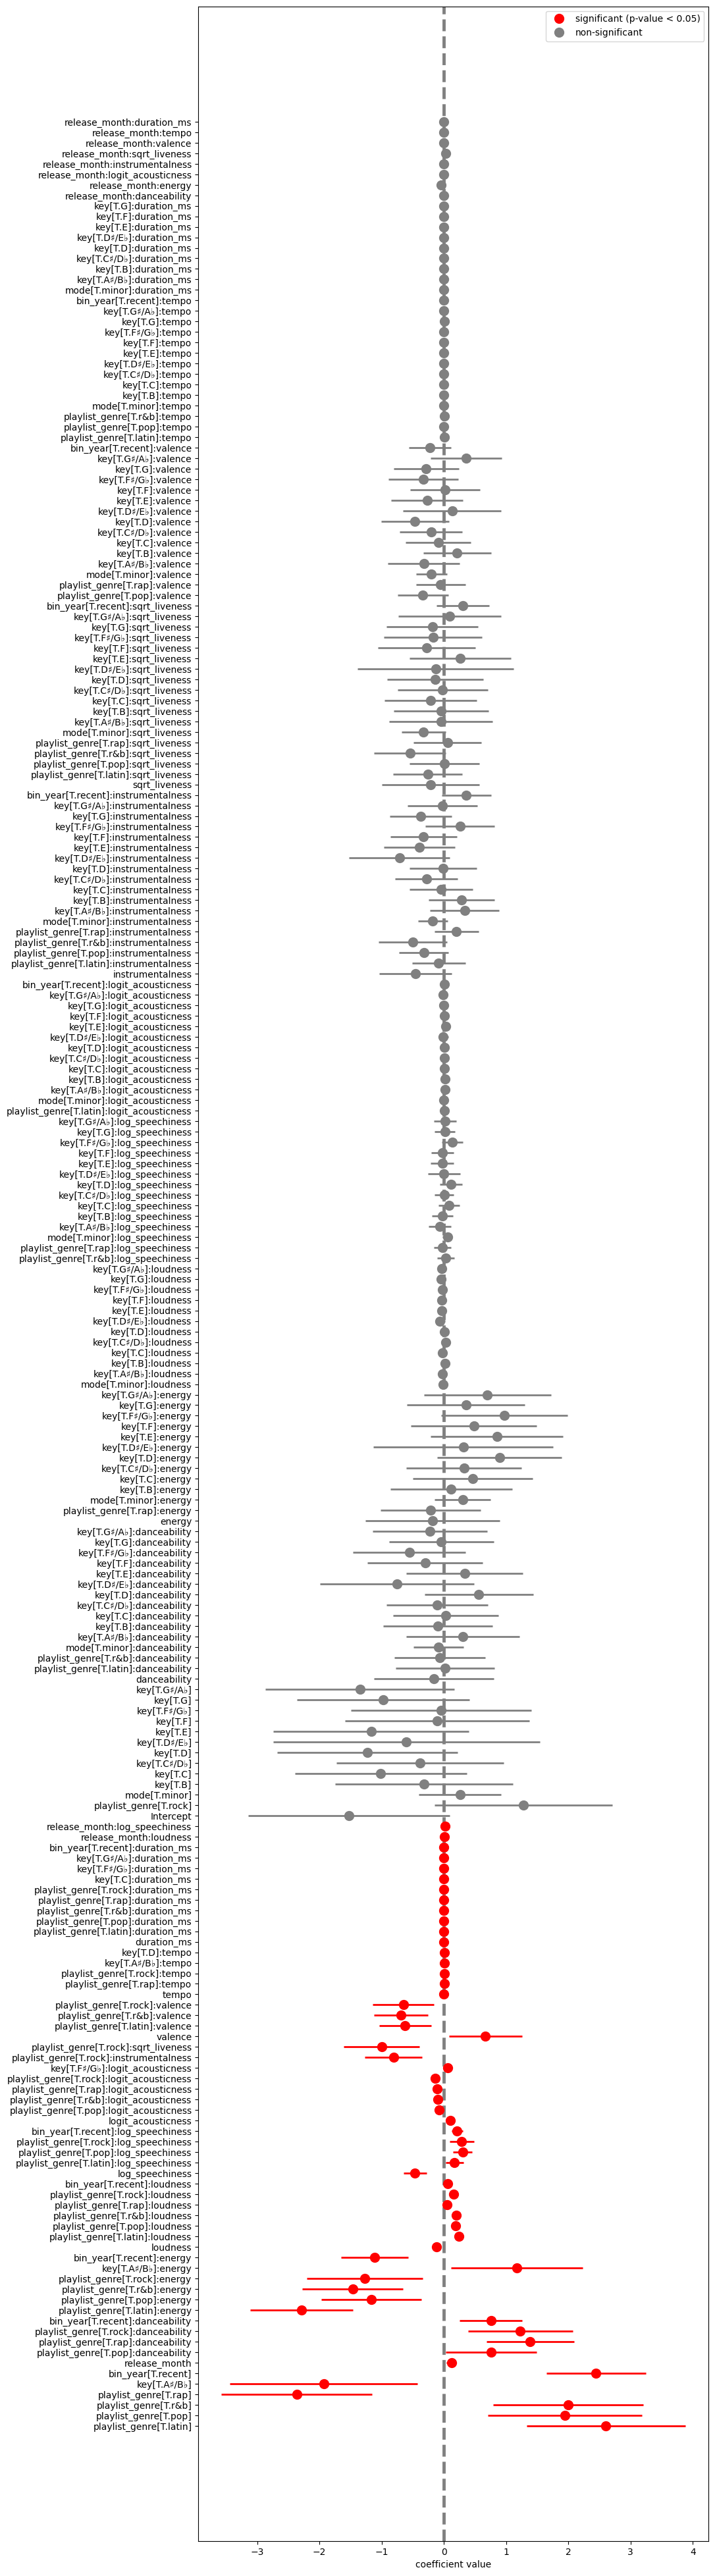

In [26]:
my_coefplot(mod_05, figsize_use=(10,50))

### Linear additive features and interactions between select categorical variables

In [27]:
mod_06 = smf.ols(formula=formula_list[6], data=spotify_copy).fit()

In [28]:
print(mod_06.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     74.25
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        20:22:30   Log-Likelihood:                -70381.
No. Observations:               32246   AIC:                         1.408e+05
Df Residuals:                   32222   BIC:                         1.410e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

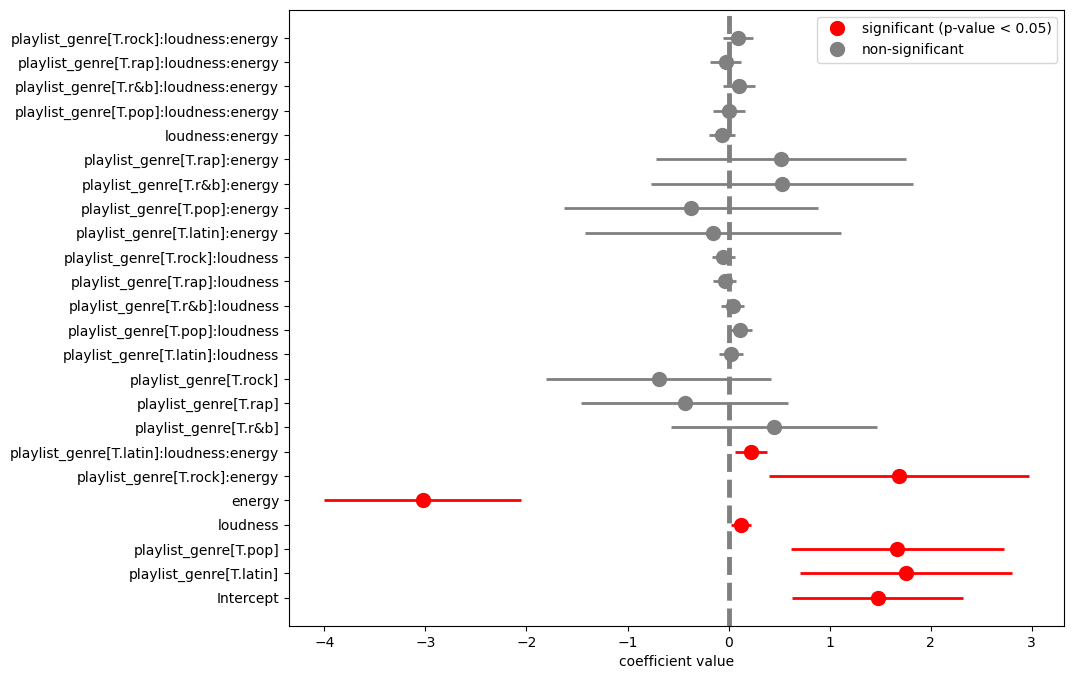

In [29]:
my_coefplot(mod_06, figsize_use=(10,8))

### Pairwise interactions among categorical and continuous inputs, with linear additive features

In [30]:
mod_07 = smf.ols(formula=formula_list[7], data=spotify_copy).fit()

In [31]:
print(mod_07.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     54.36
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        20:22:31   Log-Likelihood:                -70340.
No. Observations:               32246   AIC:                         1.407e+05
Df Residuals:                   32212   BIC:                         1.410e+05
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

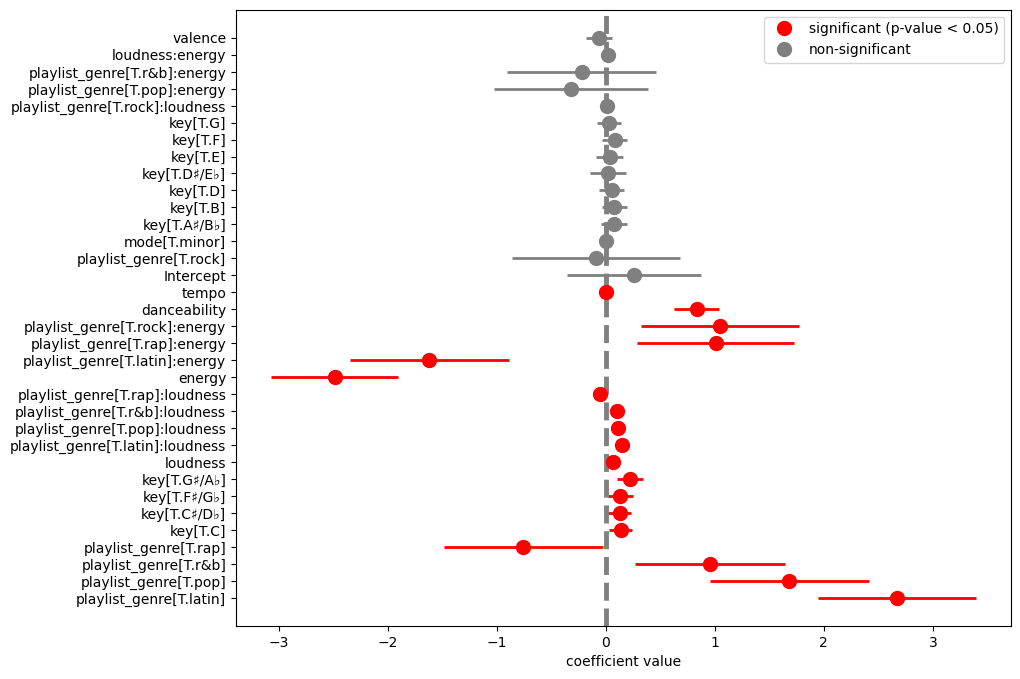

In [32]:
my_coefplot(mod_07, figsize_use=(10,8))

## Conclusion

The coefficient plots demonstrate the many statistically significant features in predicting the output `y` for each model, but `energy` stood out to me as it appears to have a large impact on the models. It also looks like `playlist_genre` and `danceability` may also play a role in predicting popularity. Other input variables such as `loudness`, `log_speechiness`, `logit_acousticness`, and `duration_ms` are also significant, but they tend to have p-values VERY close to 0.05 which suggests that they might not be good predictors after all.